## <center> Diamond Clarity Classification <center>

Diamond clarity is typically determined by trained gemologists through microscopic inspection. This process requires expert knowledge and time.

If we can build a machine learning model that predicts clarity from measurable attributes, it could assist jewelers, online retailers, and grading labs by providing fast preliminary clarity estimates.

#### Objective:
Although clarity labels are already provided in the dataset, the objective of this project is to build predictive models that can learn the relationship between physical diamond attributes and clarity grades, enabling automated clarity estimation for new diamonds.

The goal of this project is to:

Use diamond attributes such as carat, cut, color, depth, table, and dimensions

Train machine learning models to predict the clarity category

Compare classical ML models and Artificial Neural Networks (ANN)

Evaluate which model best predicts diamond clarity.

#### Import liabraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Classical ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#### Load Dataset


In [63]:
df = pd.read_csv("gemstone.csv")
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [64]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  str    
 3   color    193573 non-null  str    
 4   clarity  193573 non-null  str    
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), str(3)
memory usage: 16.2 MB


,id,carat,depth,table,x,y,z,price
count,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000
mean,96786.000000,0.790688,61.820574,57.227675,5.715312,5.720094,3.534246,3969.155414
std,55879.856166,0.462688,1.081704,1.918844,1.109422,1.102333,0.688922,4034.374138
min,0.000000,0.200000,52.100000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,48393.000000,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,951.000000
50%,96786.000000,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,2401.000000
75%,145179.000000,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,5408.000000
max,193572.000000,3.500000,71.600000,79.000000,9.650000,10.010000,31.300000,18818.000000


### EDA

In [65]:
#Check missing values:
df.isnull().sum()

id         0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

##### Distribution of Clarity (Target Variable)

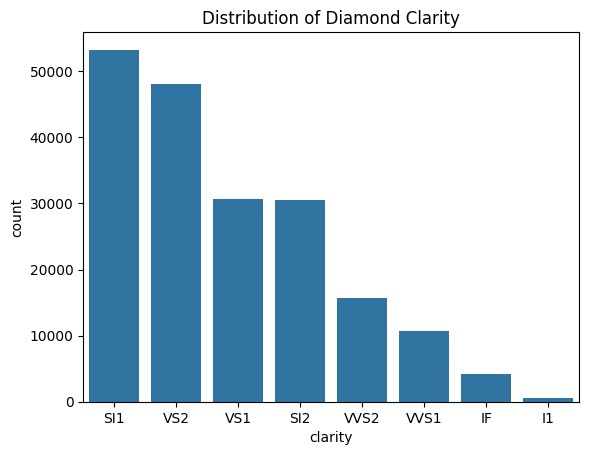

In [66]:


sns.countplot(x='clarity', data=df, order=df['clarity'].value_counts().index)
plt.title("Distribution of Diamond Clarity")
plt.show()

In [67]:
df['clarity'].value_counts().sort_index()

clarity
I1        512
IF       4219
SI1     53272
SI2     30484
VS1     30669
VS2     48027
VVS1    10628
VVS2    15762
Name: count, dtype: int64

Some clarity classes such as SI1 and VS2 occur more frequently, which may influence model predictions.

#### Distribution of Numerical Features

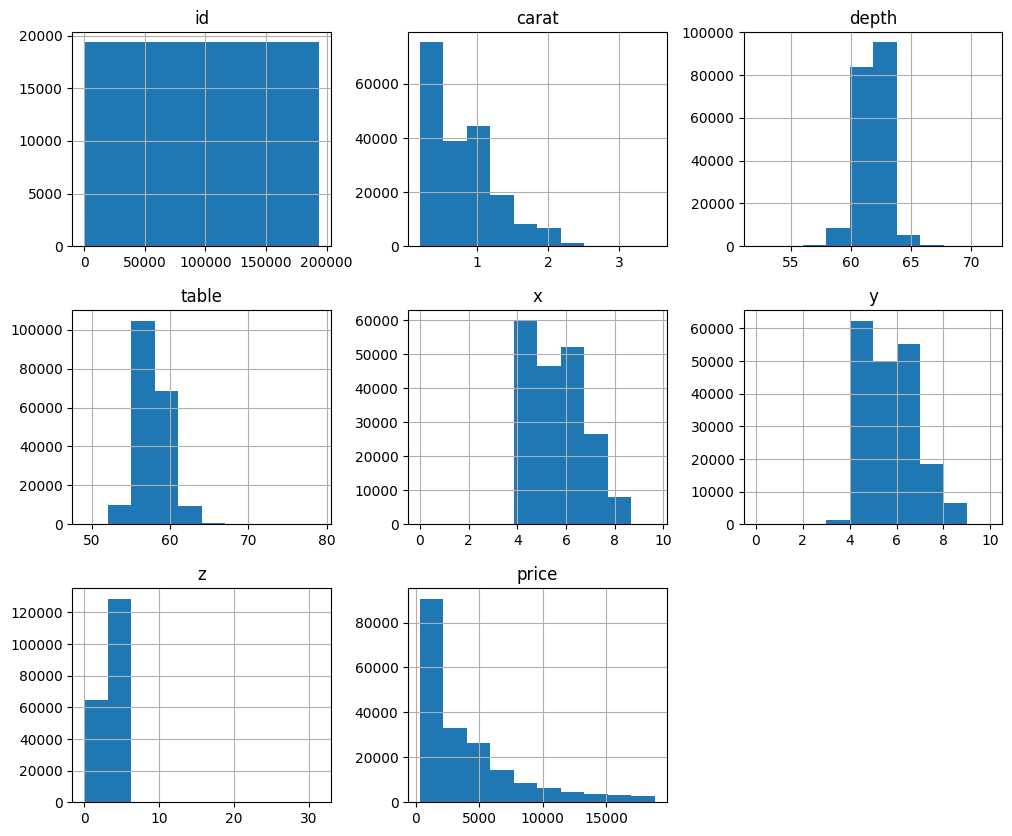

In [68]:
df.hist(figsize=(12,10))
plt.show()

Most diamonds have small carat values, indicating the dataset is skewed.

#### Clarity vs Price



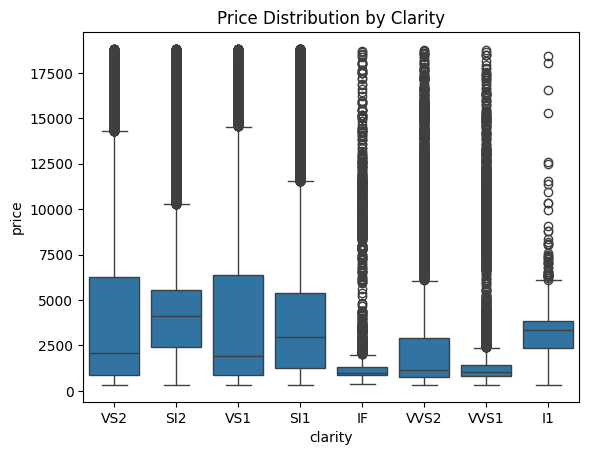

In [69]:

sns.boxplot(x='clarity', y='price', data=df)
plt.title("Price Distribution by Clarity")
plt.show()



Higher clarity diamonds tend to have higher median prices.

##### Price Distribution by Clarity

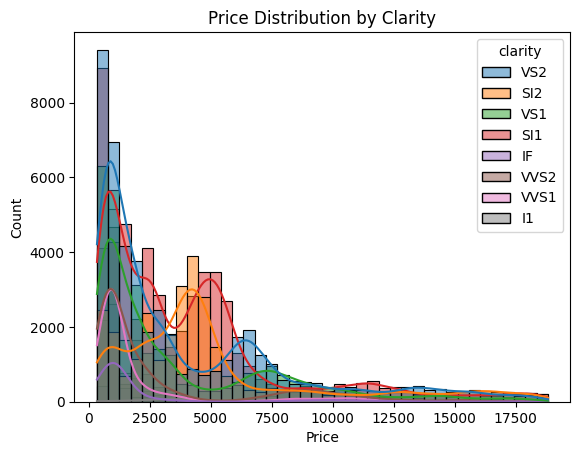

In [70]:
sns.histplot(data=df, x='price', hue='clarity', bins=40, kde=True)

plt.title("Price Distribution by Clarity")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

##### Carat Distribution by Clarity

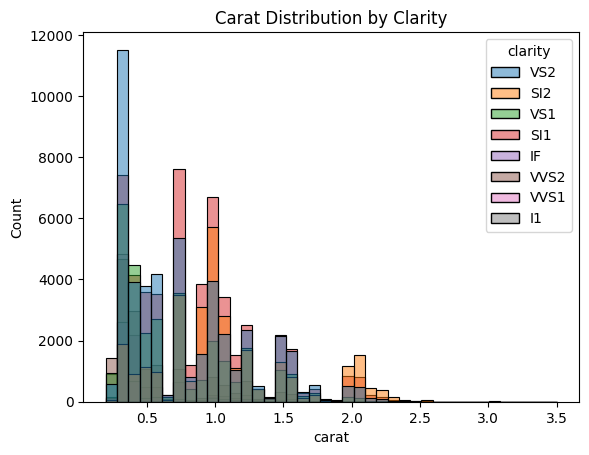

In [71]:
sns.histplot(data=df, x='carat', hue='clarity', bins=40)

plt.title("Carat Distribution by Clarity")
plt.show()

##### Relationship Between Carat and Price


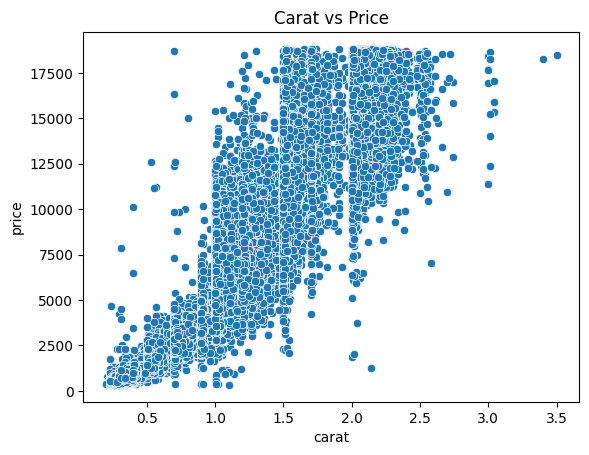

In [72]:


sns.scatterplot(x='carat', y='price', data=df)
plt.title("Carat vs Price")
plt.show()

#### Data Preprocessing

In [73]:
# Encode categorical variables
le = LabelEncoder()

df['cut'] = le.fit_transform(df['cut'])
df['color'] = le.fit_transform(df['color'])
df['clarity'] = le.fit_transform(df['clarity'])

#### Feature and Target

In [74]:
X = df.drop('clarity', axis=1)
y = df['clarity']

#### Train Test Split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [76]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Classical ML Models

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Bagging": BaggingClassifier()
}

results = {}

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    preds = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    print("\n=============================")
    print(f"Model: {name}")
    print("Accuracy:", acc)
    
    print("\nClassification Report:")
    print(classification_report(y_test, preds))


Model: Logistic Regression
Accuracy: 0.42774118558698176

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.10      0.17       102
           1       0.24      0.02      0.03       844
           2       0.48      0.64      0.55     10655
           3       0.69      0.48      0.57      6097
           4       0.28      0.21      0.24      6134
           5       0.36      0.51      0.42      9605
           6       0.33      0.15      0.21      2126
           7       0.35      0.07      0.11      3152

    accuracy                           0.43     38715
   macro avg       0.44      0.27      0.29     38715
weighted avg       0.43      0.43      0.40     38715


Model: Decision Tree
Accuracy: 0.5677644323905463

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.34      0.36       102
           1       0.56      0.58      0.57       844
           2       0.61      

d:\Diamond_ML_Project\di_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Diamond_ML_Project\di_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Diamond_ML_Project\di_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Model: Extra Trees
Accuracy: 0.6068707219423995

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.14      0.23       102
           1       0.65      0.52      0.58       844
           2       0.63      0.70      0.66     10655
           3       0.73      0.69      0.71      6097
           4       0.51      0.48      0.50      6134
           5       0.59      0.62      0.60      9605
           6       0.55      0.48      0.51      2126
           7       0.54      0.46      0.50      3152

    accuracy                           0.61     38715
   macro avg       0.61      0.51      0.54     38715
weighted avg       0.61      0.61      0.60     38715


Model: Bagging
Accuracy: 0.630608291359938

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.37      0.46       102
           1       0.66      0.64      0.65       844
           2       0.64      0.70      0.67  

In [78]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.639752
8,Bagging,0.630608
7,Extra Trees,0.606871
1,Decision Tree,0.567764
5,Gradient Boosting,0.556038
0,Logistic Regression,0.427741
3,KNN,0.371381
6,AdaBoost,0.313703
4,Naive Bayes,0.219760


After comparing multiple classification models, the top performers were Random Forest.

#### Hyperparameter Tuning

In [79]:
# Hyperparameter Tuning for Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(class_weight="balanced")
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    verbose=2,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)
best_rf = rf_random.best_estimator_

preds_best_rf = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Acc_best_rf:", accuracy_score(y_test, preds_best_rf))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


d:\Diamond_ML_Project\di_env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
7 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Diamond_ML_Project\di_env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Diamond_ML_Project\di_env\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Diamond_ML_Project\di_env\Lib\site-packages\sklearn\ensemble\_forest.py", line 486, in fit
    tre

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Acc_best_rf: 0.642386671832623


In [80]:
# Tuned Random Forest
acc_best_rf = accuracy_score(y_test, preds_best_rf)

In [81]:
results["Tuned Random Forest"] = acc_best_rf

In [82]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy
9  Tuned Random Forest  0.642387
2        Random Forest  0.639752
8              Bagging  0.630608
7          Extra Trees  0.606871
1        Decision Tree  0.567764
5    Gradient Boosting  0.556038
0  Logistic Regression  0.427741
3                  KNN  0.371381
6             AdaBoost  0.313703
4          Naive Bayes  0.219760


#### Model Comparison

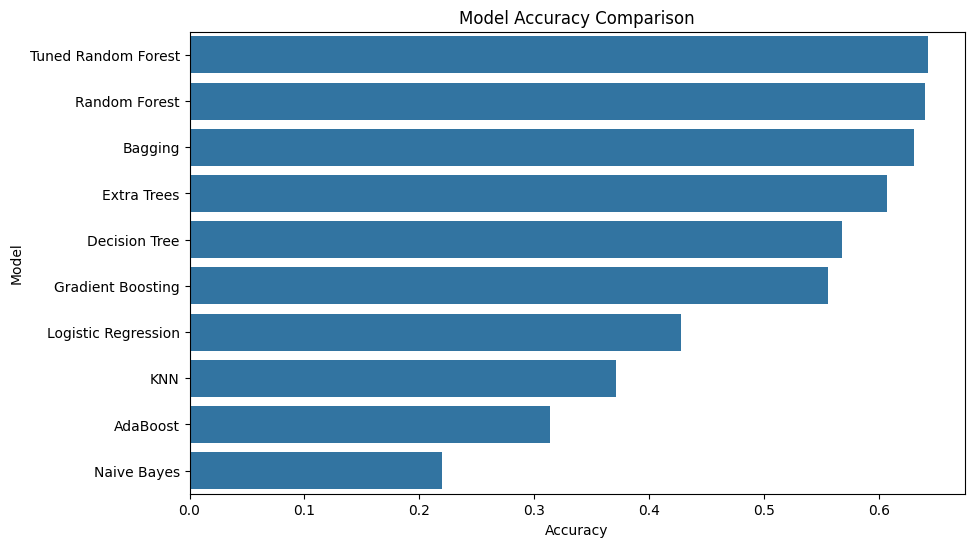

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(x="Accuracy", y="Model", data=results_df)

plt.title("Model Accuracy Comparison")
plt.show()

#### ROC Curve for Multi-Class Classification

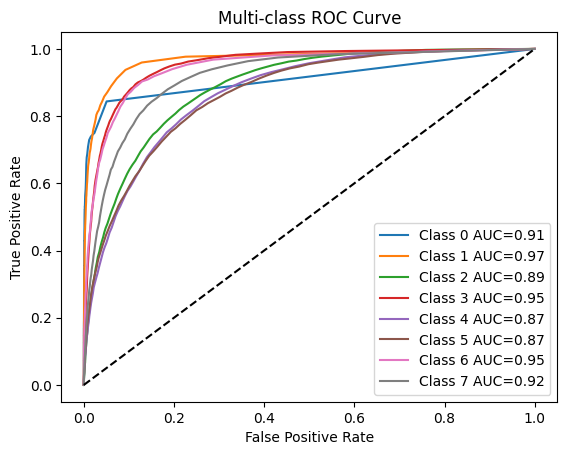

In [84]:
# Binarize labels
from sklearn.preprocessing import label_binarize

classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)

X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)
# Train Classifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

model = OneVsRestClassifier(RandomForestClassifier())
model.fit(X_train, y_train_bin)

y_score = model.predict_proba(X_test)
# Plot ROC Curve
from sklearn.metrics import roc_curve, auc

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.show()

Class IF diamonds have a very high ROC-AUC (~0.97) → model distinguishes IF diamonds easily

Class VS1 diamonds have a lower ROC-AUC (~0.70) → model struggles, likely because SI2 overlaps with nearby clarity grades

#### ANN Model

In [86]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

d:\Diamond_ML_Project\di_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.1961 - loss: 278.1615 - val_accuracy: 0.0867 - val_loss: 175.6841
Epoch 2/20
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.1947 - loss: 115.6136 - val_accuracy: 0.1576 - val_loss: 60.3501
Epoch 3/20
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.2526 - loss: 11.3647 - val_accuracy: 0.2740 - val_loss: 1.7538
Epoch 4/20
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.2755 - loss: 1.7485 - val_accuracy: 0.2740 - val_loss: 1.7477
Epoch 5/20
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.2755 - loss: 1.7466 - val_accuracy: 0.2740 - val_loss: 1.7474
Epoch 6/20
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.2755 - loss: 1.7465 - val_accuracy: 0.2740 - val_loss: 1.7474
Epoch 7/20
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.2755 - loss: 1.7465 - val_accuracy: 0.2740 - val_loss: 1.7474
Epoch 8/20
3872/3872 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.2755 - loss: 1

ANN Evaluation

In [97]:
ann_preds = model.predict(X_test)
ann_preds = np.argmax(ann_preds, axis=1)

accuracy_score(y_test, ann_preds)

1210/1210 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


0.2752163244220586

#### Plot Training vs Validation Accuracy

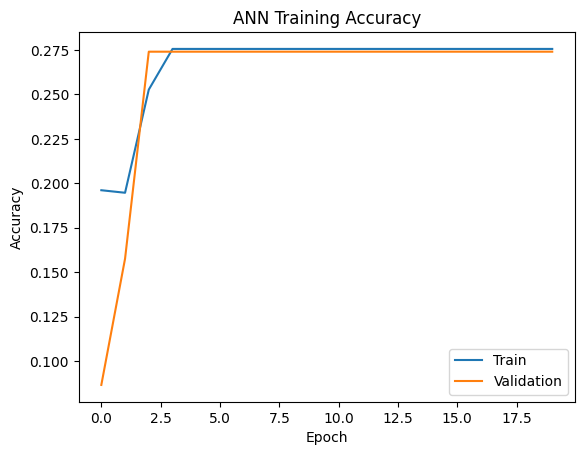

In [98]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("ANN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

#### Plot Loss

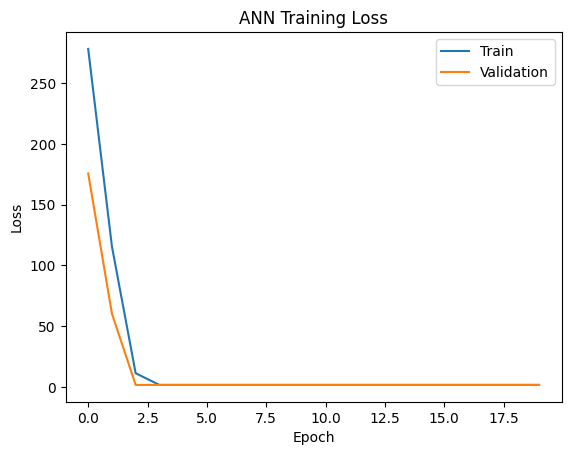

In [99]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("ANN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

##### Model Comparison

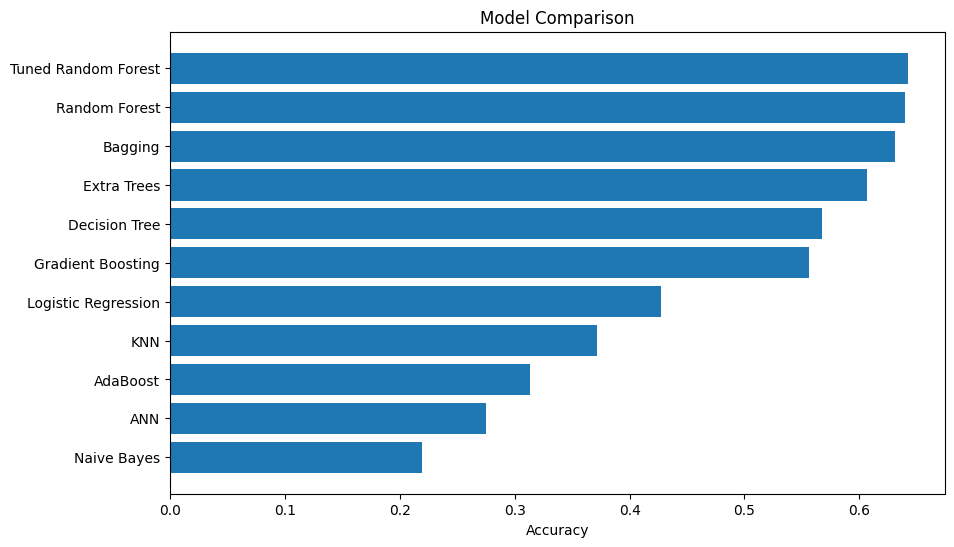

In [101]:
results['ANN'] = accuracy_score(y_test, ann_preds)

# Create dataframe
results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])

# Sort by accuracy (descending)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# Horizontal bar plot
plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["Accuracy"])

# Highest accuracy on top
plt.gca().invert_yaxis()

plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.show()

##### Confusion Matrix (Best Model)

Random Forest Accuracy: 0.642


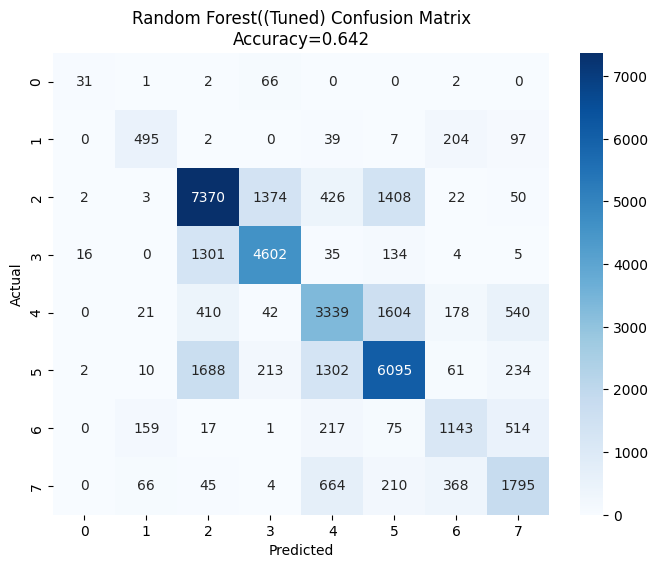

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
acc = accuracy_score(y_test, preds_best_rf)
print(f"Random Forest Accuracy: {acc:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds_best_rf)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(df['clarity'].unique()),
            yticklabels=sorted(df['clarity'].unique()))
plt.title(f"Random Forest((Tuned) Confusion Matrix\nAccuracy={acc:.3f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 

Observations:

Random Forest achieved the highest accuracy, outperforming other classical ML models.

Boosting models (Gradient Boosting, Extra Trees) also performed well.

ANN performed competitively, but for this tabular dataset, tree-based ensembles slightly outperform it.

Simple models like Logistic Regression or KNN have lower predictive power because they cannot capture complex non-linear relationships between diamond features and clarity grades.